# Melbourne Metro Train — Timetable & Demand Analysis

**Portfolio project for Metro Trains Melbourne — Timetable Evaluation Analyst**

Data sources:
- **GTFS static feed** (Transport Victoria) — scheduled timetable for all 18 metro lines
- **Station entries FY2024-25** — annual patronage per station with AM/PM peak breakdown
- **Monthly patronage 2018–2026** — network-wide ridership trend



### Step 1 — Import libraries


In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


### Step 2 — Set file path

In [2]:
DATA_PATH = "./data/"    

GTFS_FILES = ["routes", "trips", "stop_times", "stops", "calendar", "calendar_dates"]

gtfs = {}
for name in GTFS_FILES:
    gtfs[name] = pd.read_csv(f"{DATA_PATH}{name}.txt")
    # Strip stray quote characters the GTFS exporter sometimes adds
    for col in gtfs[name].select_dtypes("object").columns:
        gtfs[name][col] = gtfs[name][col].str.strip().str.strip('"').str.strip()
    print(f"  {name:20s}  {len(gtfs[name]):>8,} rows")

station_entries = pd.read_csv(f"{DATA_PATH}annual_metropolitan_train_station_entries_fy_2024_2025.csv")
monthly_pat     = pd.read_csv(f"{DATA_PATH}monthly_public_transport_patronage_by_mode2.csv")
print(f"  {'station_entries':20s}  {len(station_entries):>8,} rows")
print(f"  {'monthly_patronage':20s}  {len(monthly_pat):>8,} rows")

  routes                      36 rows
  trips                   38,615 rows
  stop_times             609,459 rows
  stops                    2,977 rows
  calendar                    24 rows
  calendar_dates              11 rows
  station_entries            222 rows
  monthly_patronage          118 rows


### Step 3 — Load GTFS tables into SQLite

In [3]:
conn = sqlite3.connect(":memory:")   # in-memory database, no file saved to disk

for name, df in gtfs.items():
    df.to_sql(name, conn, if_exists="replace", index=False)
    print(f"  Table created: {name}")

  Table created: routes
  Table created: trips
  Table created: stop_times
  Table created: stops
  Table created: calendar
  Table created: calendar_dates


### Step 4 — Trips per line (weekdays only)

In [4]:
sql_trips_per_line = """
SELECT
    r.route_short_name          AS line,
    COUNT(DISTINCT t.trip_id)   AS daily_trips
FROM trips t
JOIN routes   r ON t.route_id   = r.route_id
JOIN calendar c ON t.service_id = c.service_id
WHERE c.monday = 1
  AND r.route_short_name != 'Replacement Bus'
GROUP BY r.route_short_name
ORDER BY daily_trips DESC
"""

trips_per_line = pd.read_sql(sql_trips_per_line, conn)
trips_per_line

,line,daily_trips
0,Sunbury,1212
1,Frankston,972
2,Werribee,868
3,Lilydale,723
4,Pakenham,722
5,Sandringham,645
6,Mernda,629
7,Hurstbridge,608
8,Glen Waverley,607
9,Craigieburn,604


### Step 5 — Headway by line and hour

In [5]:
sql_headway = """
SELECT
    r.route_short_name                               AS line,
    CAST(SUBSTR(st.departure_time, 1, 2) AS INTEGER) AS hour,
    COUNT(DISTINCT t.trip_id)                        AS trips_in_hour,
    ROUND(60.0 / COUNT(DISTINCT t.trip_id), 1)       AS headway_minutes
FROM stop_times st
JOIN trips    t ON st.trip_id   = t.trip_id
JOIN routes   r ON t.route_id   = r.route_id
JOIN calendar c ON t.service_id = c.service_id
WHERE st.stop_sequence = 1
  AND c.monday = 1
  AND r.route_short_name != 'Replacement Bus'
GROUP BY r.route_short_name, hour
ORDER BY r.route_short_name, hour
"""

headway_df = pd.read_sql(sql_headway, conn)
print(f"Rows returned: {len(headway_df)}")
headway_df.head(12)

Rows returned: 381


,line,hour,trips_in_hour,headway_minutes
0,Alamein,3,2,30.0
1,Alamein,4,4,15.0
2,Alamein,5,19,3.2
3,Alamein,6,19,3.2
4,Alamein,7,27,2.2
5,Alamein,8,33,1.8
6,Alamein,9,27,2.2
7,Alamein,10,30,2.0
8,Alamein,11,30,2.0
9,Alamein,12,30,2.0


### Step 6 — Peak summary: AM peak / interpeak / PM peak per line

The headway query is set as a subquery, each hour is bucketed into one of three time periods and averages the headway across each bucket.

Time periods:
- AM peak: 07:00–09:59
- Interpeak: 10:00–15:59
- PM peak: 16:00–18:59

In [6]:
sql_peak_summary = """
SELECT
    line,
    ROUND(AVG(CASE WHEN hour BETWEEN 7  AND 9  THEN headway_minutes END), 1) AS am_peak_headway,
    ROUND(AVG(CASE WHEN hour BETWEEN 10 AND 15 THEN headway_minutes END), 1) AS interpeak_headway,
    ROUND(AVG(CASE WHEN hour BETWEEN 16 AND 18 THEN headway_minutes END), 1) AS pm_peak_headway
FROM (
    SELECT
        r.route_short_name                               AS line,
        CAST(SUBSTR(st.departure_time, 1, 2) AS INTEGER) AS hour,
        ROUND(60.0 / COUNT(DISTINCT t.trip_id), 1)       AS headway_minutes
    FROM stop_times st
    JOIN trips    t ON st.trip_id   = t.trip_id
    JOIN routes   r ON t.route_id   = r.route_id
    JOIN calendar c ON t.service_id = c.service_id
    WHERE st.stop_sequence = 1
      AND c.monday = 1
      AND r.route_short_name != 'Replacement Bus'
    GROUP BY r.route_short_name, hour
) hourly
GROUP BY line
HAVING am_peak_headway IS NOT NULL
ORDER BY am_peak_headway ASC
"""

peak_summary = pd.read_sql(sql_peak_summary, conn)
peak_summary

,line,am_peak_headway,interpeak_headway,pm_peak_headway
0,Sunbury,0.7,1.3,0.7
1,Frankston,0.9,1.3,0.7
2,Lilydale,1.1,2.0,1.2
3,Werribee,1.1,1.4,1.1
4,Mernda,1.2,2.2,1.5
5,Craigieburn,1.3,2.4,1.4
6,Hurstbridge,1.4,2.4,1.5
7,Pakenham,1.4,2.3,1.2
8,Glen Waverley,1.5,1.9,1.6
9,Sandringham,1.5,1.9,1.3


### Step 7 — Station patronage and peak ratio

Rank stations by annual entries. Calculate peak ratio — what percentage of a station's  
total annual travel happens during peak hours (AM peak + PM peak).  

High peak ratio = high timetable pressure. These are the stations where frequency  
improvements would have the biggest passenger impact.


In [7]:
station_entries.columns = station_entries.columns.str.strip()

top20 = station_entries.nlargest(20, "Pax_annual").copy()
top20["Stop_name"] = top20["Stop_name"].str.replace(" Station", "", regex=False)

top20["am_pct"]   = (top20["Pax_AM_peak"] / top20["Pax_weekday"] * 100).round(1)
top20["pm_pct"]   = (top20["Pax_PM_peak"] / top20["Pax_weekday"] * 100).round(1)
top20["peak_pct"] = (top20["am_pct"] + top20["pm_pct"]).round(1)

top20[["Stop_name", "Pax_annual", "Pax_weekday", "am_pct", "pm_pct", "peak_pct"]]

,Stop_name,Pax_annual,Pax_weekday,am_pct,pm_pct,peak_pct
29,Flinders Street,19633300,60900,5.9,55.3,61.2
208,Southern Cross,14696050,47600,6.5,64.7,71.2
17,Melbourne Central,11876900,38300,4.3,56.8,61.1
18,Parliament,6344650,22350,3.8,71.6,75.4
191,Footscray,4383950,14000,27.5,33.9,61.4
81,Richmond,3712750,9850,9.1,44.7,53.8
16,Flagstaff,3445200,12350,6.9,68.4,75.3
116,Caulfield,3205100,9600,24.5,37.5,62.0
132,South Yarra,3199050,10350,25.1,44.4,69.5
207,Box Hill,2648350,8350,31.1,32.9,64.0


### Step 8 — Patronage recovery: pre-COVID vs recent

In [8]:
monthly_pat.columns = monthly_pat.columns.str.strip()

monthly = monthly_pat[
    monthly_pat["Year"].notna() & monthly_pat["Year"].between(2000, 2030)
].copy()
monthly["Year"]  = monthly["Year"].astype(int)
monthly["Month"] = monthly["Month"].astype(int)
monthly["date"]  = pd.to_datetime(monthly[["Year", "Month"]].assign(day=1))
monthly["train_trips"] = (
    monthly["Metropolitan train"].str.replace(",", "", regex=False).astype(float)
)
monthly = monthly.dropna(subset=["train_trips"]).sort_values("date")

pre_covid = monthly[monthly["date"] < "2020-03-01"]["train_trips"].mean()
recent    = monthly[
    monthly["date"] >= monthly["date"].max() - pd.DateOffset(months=12)
]["train_trips"].mean()
recovery  = round(recent / pre_covid * 100, 1)

print(f"Pre-COVID monthly average : {pre_covid/1e6:.1f}M passengers")
print(f"Recent 12-month average   : {recent/1e6:.1f}M passengers")
print(f"Recovery rate             : {recovery}% of pre-COVID baseline")

Pre-COVID monthly average : 20.2M passengers
Recent 12-month average   : 15.3M passengers
Recovery rate             : 75.8% of pre-COVID baseline


## Step 8 - Create Charts

In [15]:
PURPLE = "#152C6B"
TEAL   = "#028430"
AMBER  = "#FFBE00"
CORAL  = "#D85A30"
DGRAY  = "#444441"

plt.rcParams.update({
    "font.family"       : "sans-serif",
    "font.size"         : 10,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.color"        : "#E0E0E0",
    "grid.linewidth"    : 0.5,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
})

### Chart A — Daily weekday trips per line
Shows service volume per line. The median reference line shows which lines run above or below average.


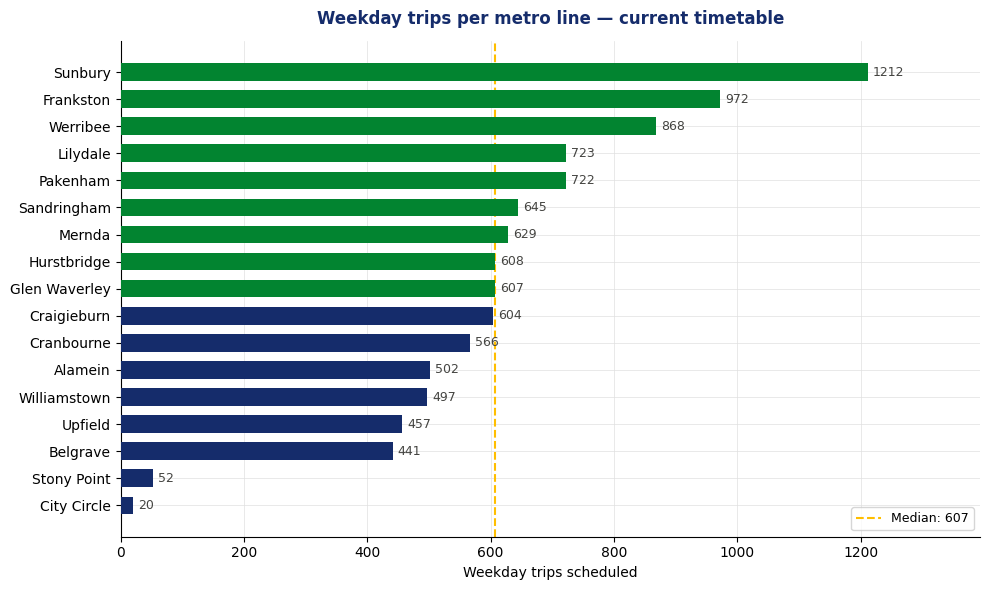

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

df_plot = trips_per_line.sort_values("daily_trips")
med = df_plot["daily_trips"].median()
colors = [TEAL if v >= med else PURPLE for v in df_plot["daily_trips"]]

bars = ax.barh(df_plot["line"], df_plot["daily_trips"], color=colors, height=0.65, zorder=3)
for bar, val in zip(bars, df_plot["daily_trips"]):
    ax.text(val + 8, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9, color=DGRAY)

ax.axvline(med, color=AMBER, linewidth=1.5, linestyle="--", label=f"Median: {int(med)}")
ax.set_xlabel("Weekday trips scheduled")
ax.set_title("Weekday trips per metro line — current timetable",
             fontsize=12, fontweight="bold", color=PURPLE, pad=12)
ax.set_xlim(0, df_plot["daily_trips"].max() * 1.15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/chart_A_trips_per_line.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart B — Headway heatmap 
Headway in minutes per line per time period. Red = long wait (worse), green = short wait (better).  

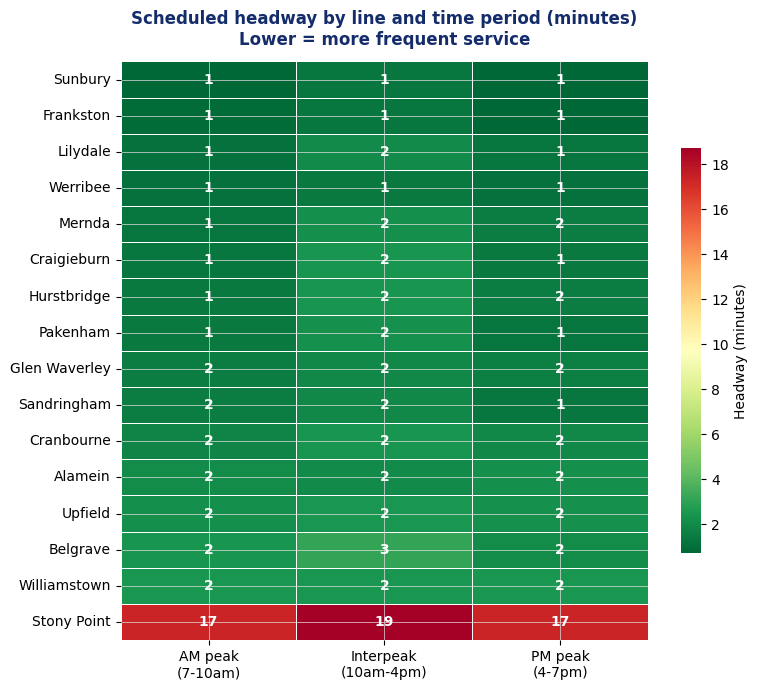

In [16]:
heatmap_data = peak_summary.set_index("line")[
    ["am_peak_headway", "interpeak_headway", "pm_peak_headway"]
].rename(columns={
    "am_peak_headway"   : "AM peak\n(7-10am)",
    "interpeak_headway" : "Interpeak\n(10am-4pm)",
    "pm_peak_headway"   : "PM peak\n(4-7pm)",
}).sort_values("AM peak\n(7-10am)")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    heatmap_data, ax=ax, cmap="RdYlGn_r",
    annot=True, fmt=".0f",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Headway (minutes)", "shrink": 0.7},
    annot_kws={"size": 10, "weight": "bold"}
)
ax.set_title(
    "Scheduled headway by line and time period (minutes)\nLower = more frequent service",
    fontsize=12, fontweight="bold", color=PURPLE, pad=12
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("outputs/chart_B_headway_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart C — Top 20 stations by annual patronage
Orange bars = stations where more than 30% of all travel is in peak hours.  
Highlighting where train frequency changes would have the biggest impact. 

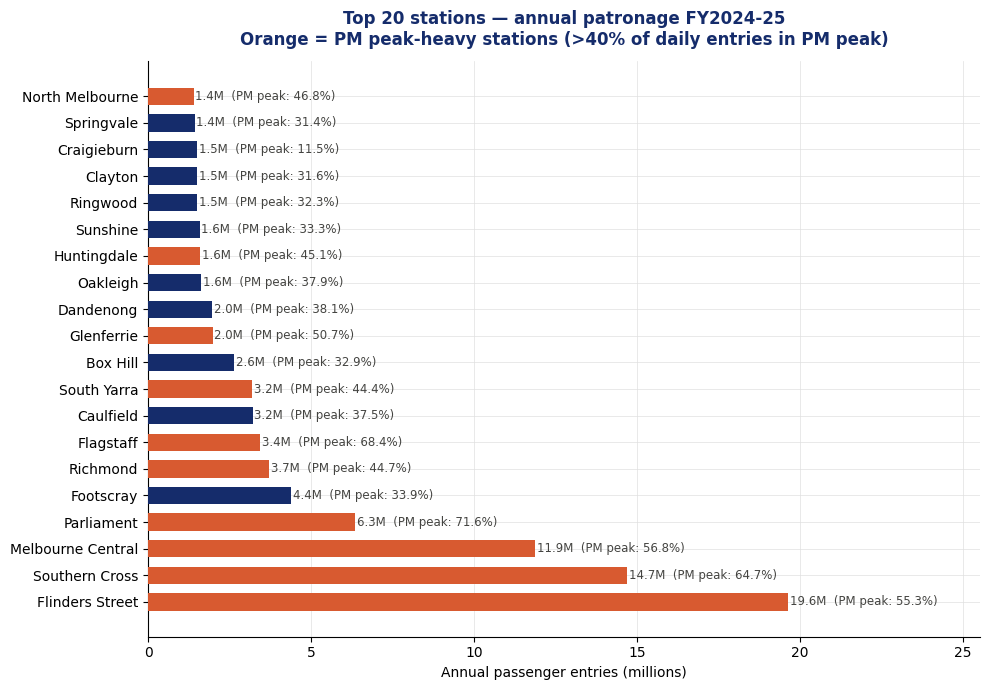

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))

bar_colors = [CORAL if r >= 40 else PURPLE for r in top20["pm_pct"]]
bars = ax.barh(top20["Stop_name"], top20["Pax_annual"]/1e6,
               color=bar_colors, height=0.65, zorder=3)

for bar, val, ratio in zip(bars, top20["Pax_annual"], top20["pm_pct"]):
    ax.text(val/1e6 + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M  (PM peak: {ratio}%)", va="center", fontsize=8.5, color=DGRAY)

ax.set_xlabel("Annual passenger entries (millions)")
ax.set_title(
    "Top 20 stations — annual patronage FY2024-25\n"
    "Orange = PM peak-heavy stations (>40% of daily entries in PM peak)",
    fontsize=12, fontweight="bold", color=PURPLE, pad=12
)
ax.set_xlim(0, top20["Pax_annual"].max()/1e6 * 1.3)
plt.tight_layout()
plt.savefig("outputs/chart_C_top_stations.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart D — Monthly patronage trend 2018–2026
Network-wide ridership over 8 years. Shows the COVID collapse and partial recovery.  
Shows 76% ridership of pre-covid levels currently. 

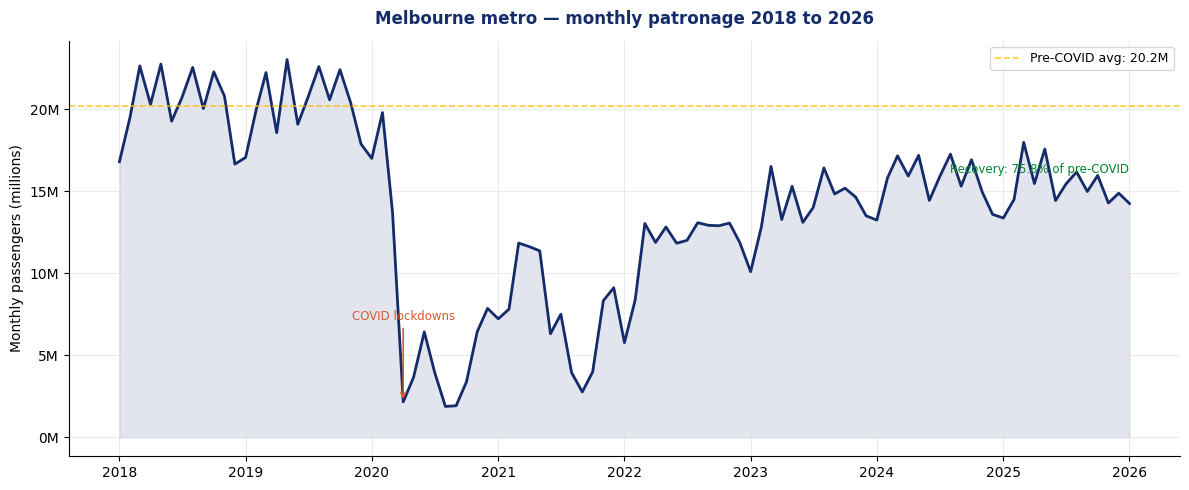

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(monthly["date"], monthly["train_trips"]/1e6, alpha=0.12, color=PURPLE)
ax.plot(monthly["date"], monthly["train_trips"]/1e6, color=PURPLE, linewidth=2)
ax.axhline(pre_covid/1e6, color=AMBER, linewidth=1.2, linestyle="--", alpha=0.8,
           label=f"Pre-COVID avg: {pre_covid/1e6:.1f}M")

covid_date = pd.Timestamp("2020-04-01")
covid_row  = monthly[monthly["date"] == covid_date]
if len(covid_row):
    y = covid_row["train_trips"].values[0] / 1e6
    ax.annotate("COVID lockdowns",
        xy=(covid_date, y), xytext=(covid_date, y + 5),
        arrowprops=dict(arrowstyle="->", color=CORAL, lw=1.2),
        fontsize=8.5, color=CORAL, ha="center")

ax.text(monthly["date"].iloc[-1], recent/1e6 + 0.8,
        f"Recovery: {recovery}% of pre-COVID",
        fontsize=8.5, color=TEAL, ha="right")

ax.set_ylabel("Monthly passengers (millions)")
ax.set_title("Melbourne metro — monthly patronage 2018 to 2026",
             fontsize=12, fontweight="bold", color=PURPLE, pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/chart_D_patronage_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9 — Key findings

In [14]:
busiest_line  = trips_per_line.iloc[0]
quietest_line = trips_per_line.iloc[-1]
best_am       = peak_summary.iloc[0]
worst_am      = peak_summary.iloc[-1]
top_station   = top20.iloc[0]
peak_heavy_pm = top20[top20["pm_pct"] >= 40]    # stations where PM peak > 40% of daily entries

print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print()
print("Service volume")
print(f"  Busiest line : {busiest_line['line']} ({busiest_line['daily_trips']} trips/weekday)")
print(f"  Quietest line: {quietest_line['line']} ({quietest_line['daily_trips']} trips/weekday)")
print()
print("Frequency (headway)")
print(f"  Best AM peak headway : {best_am['line']} ({best_am['am_peak_headway']} min)")
print(f"  Worst AM peak headway: {worst_am['line']} ({worst_am['am_peak_headway']} min)")
print()
print("Station demand")
print(f"  Busiest station: {top_station['Stop_name']} ({top_station['Pax_annual']/1e6:.1f}M entries/year)")
print(f"  Stations where PM peak > 40% of daily entries: {len(peak_heavy_pm)} of top 20")
print(f"  Most PM-skewed: {top20.sort_values('pm_pct', ascending=False).iloc[0]['Stop_name']} ({top20['pm_pct'].max()}% in PM peak)")
print()
print("Patronage trend")
print(f"  Pre-COVID avg : {pre_covid/1e6:.1f}M/month")
print(f"  Recent avg    : {recent/1e6:.1f}M/month")
print(f"  Recovery      : {recovery}% of pre-COVID baseline")

KEY FINDINGS

Service volume
  Busiest line : Sunbury (1212 trips/weekday)
  Quietest line: City Circle (20 trips/weekday)

Frequency (headway)
  Best AM peak headway : Sunbury (0.7 min)
  Worst AM peak headway: Stony Point (17.3 min)

Station demand
  Busiest station: Flinders Street (19.6M entries/year)
  Stations where PM peak > 40% of daily entries: 10 of top 20
  Most PM-skewed: Parliament (71.6% in PM peak)

Patronage trend
  Pre-COVID avg : 20.2M/month
  Recent avg    : 15.3M/month
  Recovery      : 75.8% of pre-COVID baseline
